# Notebook 7.3: Statistical Significance and the False Discovery Problem

## Financial Trading with Python, 2nd Edition

---

In Notebook 7.1 we built performance metrics from scratch. In Notebook 7.2 we used professional libraries to automate those calculations. Both notebooks taught you how to measure what happened. This notebook teaches you how to decide whether what happened was real.

The problem is simple to state. You test a strategy and it produces a Sharpe ratio of 0.95. Good. But then you test five more variants and one of them produces a Sharpe of 1.1. Is that variant genuinely better, or did it just get lucky? If you test enough strategies, parameter combinations, or filter variants, some of them will look good by pure chance. This is the false discovery problem, and it is the single most common reason that backtested strategies fail in live trading.

This notebook gives you the statistical tools to tell the difference between a real edge and a lucky backtest. These are the same tools we used in Notebook 6.4 to evaluate whether the Kalman filter actually outperformed the SMA baseline. After working through this notebook, you will understand exactly why we reached the verdict we did.

This notebook covers:

- Why good-looking backtest numbers can lie
- The multiple comparisons problem and how it inflates false discoveries
- Paired t-tests for comparing strategy returns
- Bootstrap confidence intervals on Sharpe ratio differences
- Practical guidelines for knowing when you have enough evidence

## Section 1: The Problem — Why Good-Looking Numbers Can Lie

Before we build any statistical tests, we need to see the problem with our own eyes. We are going to generate 100 completely random strategies on SPY and measure their Sharpe ratios. These strategies have no signal, no logic, no edge. They flip a coin each day to decide whether to be long SPY or in BIL. By construction, none of them should outperform buy-and-hold on a risk-adjusted basis.

And yet, some of them will.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
# --- Load case study data ---
df_prices = pd.read_parquet('case_study_prices.parquet')
df_returns = df_prices[['SPY', 'BIL']].pct_change().dropna()

print(f"Data loaded: {len(df_returns)} trading days")
print(f"Date range: {df_returns.index[0].strftime('%Y-%m-%d')} to "
      f"{df_returns.index[-1].strftime('%Y-%m-%d')}")

Data loaded: 3770 trading days
Date range: 2011-01-05 to 2025-12-31


In [3]:
# --- Generate 100 random strategies ---
# Each strategy flips a coin every day: heads = long SPY, tails = hold BIL.
# There is no signal, no analysis, no edge. These are pure noise.
#
# We fix the random seed so the results are reproducible. If you change
# the seed, the specific numbers will change but the lesson will not:
# some random strategies will always look good by chance.

np.random.seed(42)
n_strategies = 100
n_days = len(df_returns)

# Generate random daily signals: 1 = long SPY, 0 = hold BIL
# Each column is one random strategy's daily signal
random_signals = np.random.randint(0, 2, size=(n_days, n_strategies))

# Calculate daily returns for each random strategy.
# Same lagged-weight approach as Notebooks 7.1 and 7.2:
# today's return uses yesterday's signal.
spy_rets = df_returns['SPY'].values
bil_rets = df_returns['BIL'].values

random_sharpes = []
random_cagrs = []

for i in range(n_strategies):
    # Lag the signal by one day (yesterday's coin flip, today's return)
    signal_lagged = np.roll(random_signals[:, i], 1)
    signal_lagged[0] = 0  # no position on the first day

    # Daily portfolio return: signal * SPY + (1 - signal) * BIL
    port_returns = signal_lagged * spy_rets + (1 - signal_lagged) * bil_rets

    # Annualized return (CAGR)
    total_return = np.prod(1 + port_returns) - 1
    cagr = (1 + total_return) ** (252 / n_days) - 1

    # Annualized volatility
    ann_vol = np.std(port_returns, ddof=1) * np.sqrt(252)

    # Sharpe ratio (risk-free = 0, geometric return)
    sharpe = cagr / ann_vol if ann_vol > 0 else 0

    random_sharpes.append(sharpe)
    random_cagrs.append(cagr)

random_sharpes = np.array(random_sharpes)

# --- Summary statistics ---
print("100 Random Strategies: Sharpe Ratio Distribution")
print("=" * 55)
print(f"Mean Sharpe:     {random_sharpes.mean():.3f}")
print(f"Median Sharpe:   {np.median(random_sharpes):.3f}")
print(f"Min Sharpe:      {random_sharpes.min():.3f}")
print(f"Max Sharpe:      {random_sharpes.max():.3f}")
print(f"Std Dev:         {random_sharpes.std():.3f}")
print(f"\nStrategies with Sharpe > 0.5:  {(random_sharpes > 0.5).sum()}")
print(f"Strategies with Sharpe > 0.7:  {(random_sharpes > 0.7).sum()}")
print(f"Strategies with Sharpe > 1.0:  {(random_sharpes > 1.0).sum()}")

100 Random Strategies: Sharpe Ratio Distribution
Mean Sharpe:     0.627
Median Sharpe:   0.625
Min Sharpe:      0.132
Max Sharpe:      1.120
Std Dev:         0.201

Strategies with Sharpe > 0.5:  72
Strategies with Sharpe > 0.7:  33
Strategies with Sharpe > 1.0:  4


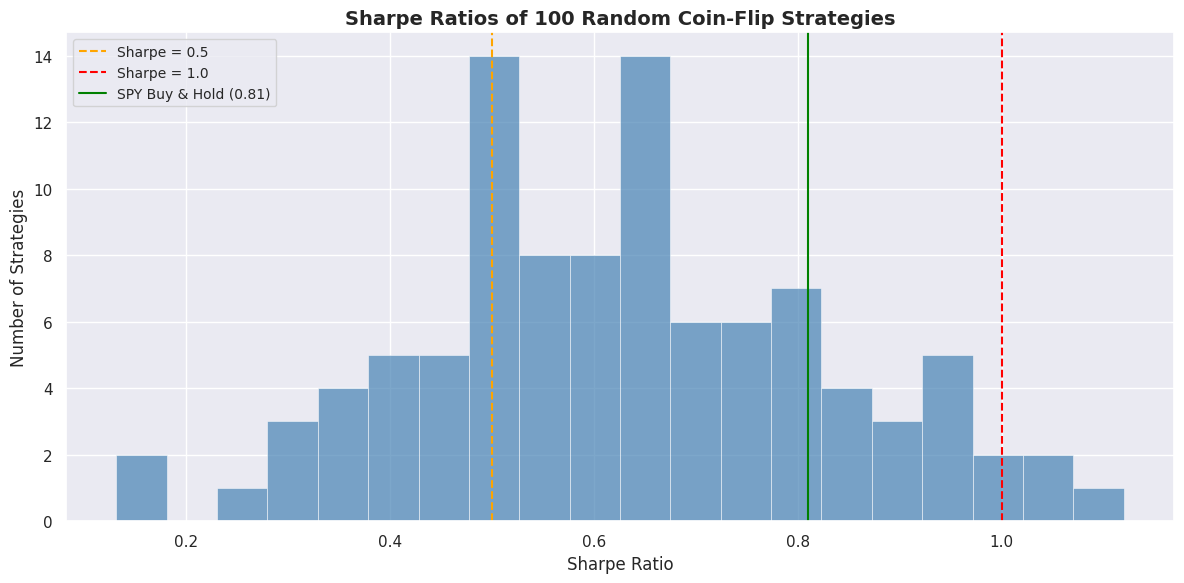

In [4]:
# --- Plot the distribution of random Sharpe ratios ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(random_sharpes, bins=20, color='steelblue', alpha=0.7,
        edgecolor='white', linewidth=0.5)

# Mark key thresholds
ax.axvline(x=0.5, color='orange', linewidth=1.5, linestyle='--',
           label='Sharpe = 0.5')
ax.axvline(x=1.0, color='red', linewidth=1.5, linestyle='--',
           label='Sharpe = 1.0')

# Mark the SPY buy-and-hold Sharpe for reference
spy_cagr = (np.prod(1 + spy_rets) - 1)
spy_cagr = (1 + spy_cagr) ** (252 / n_days) - 1
spy_vol = np.std(spy_rets, ddof=1) * np.sqrt(252)
spy_sharpe = spy_cagr / spy_vol
ax.axvline(x=spy_sharpe, color='green', linewidth=1.5, linestyle='-',
           label=f'SPY Buy & Hold ({spy_sharpe:.2f})')

ax.set_title('Sharpe Ratios of 100 Random Coin-Flip Strategies',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Number of Strategies')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Let that sink in. Four out of 100 coin-flip strategies produced a Sharpe ratio above 1.0. Thirty-three exceeded 0.7, which is in the range that many practitioners would consider respectable. The best random strategy hit 1.12, which is higher than the VIXY tail hedge (0.95) that we just spent two notebooks evaluating.

These strategies have no signal. No edge. No economic rationale. They flip a coin. And yet, if you had tested all 100 and cherry-picked the best one, you could present a backtest with a Sharpe above 1.0, a nice-looking equity curve, and a straight face. Nobody looking at that single backtest would know it was the winner of a coin-flip tournament.

The mean Sharpe of 0.627 is positive because all of these strategies are partially long SPY, which went up over the period. A coin-flip strategy that is long SPY half the time captures roughly half of SPY's return with roughly half of SPY's volatility, producing a Sharpe ratio in the neighborhood of SPY's own (0.81). The spread around that mean is what matters: pure randomness in the signal creates a standard deviation of 0.20 in the Sharpe ratio. That is enough to push a no-edge strategy from mediocre (0.4) to impressive (1.1).

This is the false discovery problem in its purest form. If you test enough things, randomness will produce something that looks like skill. The only defense is statistical testing: asking not just "did this strategy produce a good Sharpe?" but "is this Sharpe different from what randomness alone would produce?" That is what we build in the rest of this notebook.

## Section 2: The Multiple Comparisons Problem

The coin-flip experiment showed what happens when you test 100 strategies and pick the best one. But you do not need 100 strategies to fall into this trap. In Notebook 6.4, we tested six VIX filters against the SMA baseline. Six is a small number. It is still enough to create false discoveries.

The math is straightforward. If you test a single hypothesis at a 5% significance level, there is a 5% chance of a false positive (concluding there is a difference when there is not). If you test six independent hypotheses at 5% each, the probability that at least one of them produces a false positive is:

1 - (1 - 0.05)^6 = 1 - 0.95^6 = 26.5%

You have a roughly one-in-four chance of finding a "significant" result that is actually noise. Test 20 hypotheses and the probability jumps to 64%. Test 100 and it is virtually guaranteed.

This does not mean all significant results are false. It means you need to account for the number of tests you ran when interpreting your results. Two common corrections exist for this.

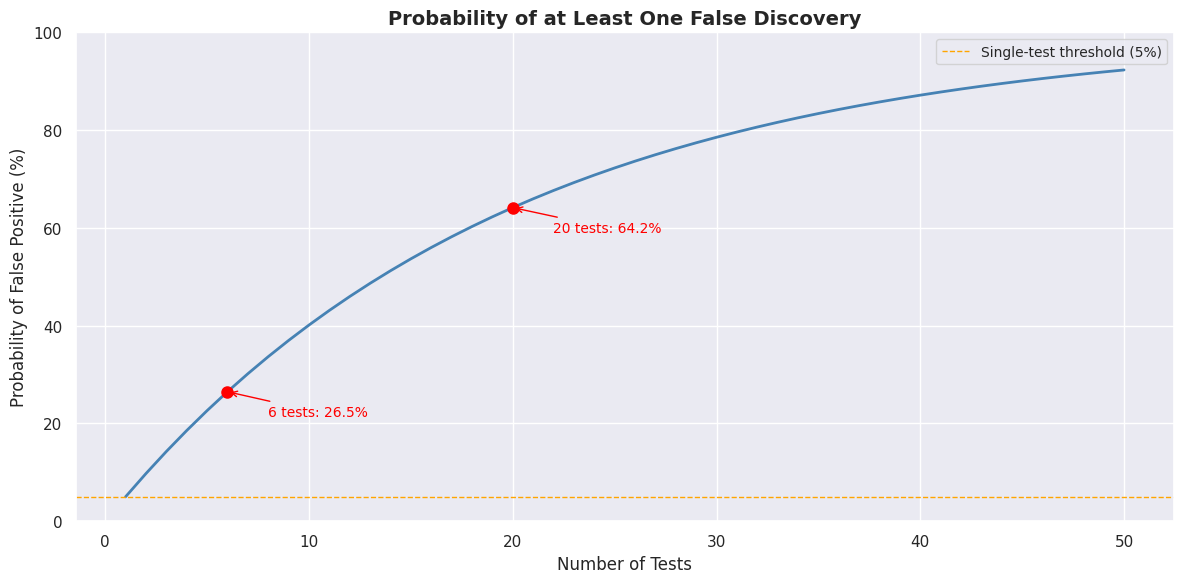

In [5]:
# --- Visualizing the multiple comparisons problem ---
# For each number of tests (1 to 50), calculate the probability
# that at least one test produces a false positive at the 5% level.
#
# This is the "family-wise error rate" (FWER): the probability of
# at least one false discovery across all tests.
#
# Formula: FWER = 1 - (1 - alpha)^n
# where alpha = 0.05 and n = number of tests

n_tests = np.arange(1, 51)
alpha = 0.05
fwer = 1 - (1 - alpha) ** n_tests

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(n_tests, fwer * 100, color='steelblue', linewidth=2)

# Mark specific points
for n, label_y in [(6, None), (20, None)]:
    prob = (1 - (1 - alpha) ** n) * 100
    ax.plot(n, prob, 'o', color='red', markersize=8)
    ax.annotate(f'{n} tests: {prob:.1f}%',
                xy=(n, prob), xytext=(n + 2, prob - 5),
                fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=1))

ax.axhline(y=5, color='orange', linestyle='--', linewidth=1,
           label='Single-test threshold (5%)')
ax.set_title('Probability of at Least One False Discovery',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Tests')
ax.set_ylabel('Probability of False Positive (%)')
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The curve rises fast. At 6 tests (the number of filters we compared in Notebook 6.4), you have a 26.5% chance of at least one false positive. At 20 tests (a modest parameter sweep), 64.2%. By 50 tests you are almost guaranteed to find something "significant" that is not real.

The orange line at 5% is where you think your false positive rate is when you run a single test. The blue curve is where it actually is when you run multiple tests. The gap between them is the multiple comparisons problem.

### 2.1 Corrections for Multiple Comparisons

Two standard corrections exist. Both adjust the significance threshold to account for the number of tests.

**Bonferroni correction:** divide the significance level by the number of tests. If you run 6 tests and want an overall 5% false positive rate, each individual test must use a threshold of 0.05 / 6 = 0.0083. This is the simplest and most conservative correction. It controls the probability of even one false positive (the family-wise error rate). The downside is that it makes it very hard to detect real effects, especially when you run many tests. It overcorrects.

**Benjamini-Hochberg (False Discovery Rate):** instead of controlling the probability of any false positive, it controls the expected proportion of false positives among all discoveries. If you find five "significant" results and the FDR is set to 5%, you expect about 0.25 of those five to be false. This is less conservative than Bonferroni and more appropriate when you are exploring many hypotheses and are willing to tolerate a small number of false discoveries. The implementation is more involved: you rank p-values, compare each to a threshold that depends on its rank, and reject from the top down.

For our purposes in this book, Bonferroni is the right choice. We are comparing a small number of filter variants (six in Notebook 6.4), and we want to be confident that any filter we adopt is genuinely better than the baseline. We would rather miss a real improvement (false negative) than adopt a filter that only looked good by chance (false positive). When the cost of a wrong decision is real money, conservative testing is the right default.

In practice, neither correction changed the Notebook 6.4 conclusions. The Fourier filter was significant at p=0.007 and the wavelet trend at p=0.03, both before correction. After Bonferroni correction (threshold of 0.05/6 = 0.0083), Fourier remains significant and wavelet trend does not. The Kalman filter at p=0.44 was nowhere near significant by any standard. The corrections matter most in borderline cases, and we did not have borderline cases.

Now let us build the two statistical tests we used in Notebook 6.4: the paired t-test and the bootstrap confidence interval. We apply them to the 50/200 SMA crossover versus SPY buy-and-hold so you can learn the mechanics on familiar data before revisiting the filter comparison in the chapter text.

## Section 3: Paired t-Test on Return Differences

The paired t-test answers a specific question: is the average daily return difference between two strategies significantly different from zero? If strategy A and strategy B were run over the same period on the same data, the paired test looks at the difference in returns on each day and asks whether those differences are consistently positive, consistently negative, or just noise centered around zero.

The key word is "paired." We are not comparing two independent samples. We are comparing two strategies that experienced the same market conditions on the same dates. The COVID crash hit both strategies on the same day. The 2021 rally benefited both strategies on the same days. By taking the difference on each day, we cancel out the shared market effect and isolate the effect of the signal itself. This is why we use a paired test rather than an independent-samples test.

In [8]:
# --- Rebuild crossover and benchmark returns ---
# We rebuild the 50/200 SMA crossover strategy from Notebooks 7.1/7.2
# so this notebook is fully self-contained. Same logic, same data.

# Calculate the two moving averages on SPY's closing price
sma_50 = df_prices['SPY'].rolling(window=50).mean()
sma_200 = df_prices['SPY'].rolling(window=200).mean()

# Signal: 1 = long SPY (SMA50 above SMA200), 0 = hold BIL (cash)
signal = (sma_50 > sma_200).astype(int)

# Build daily weights from the signal.
# When signal = 1: SPY = 1.0, BIL = 0.0 (fully invested)
# When signal = 0: SPY = 0.0, BIL = 1.0 (fully in cash)
# Trim to the first date where SMA200 is valid.
# Without this, the warmup period defaults to BIL while the benchmark
# is already invested in SPY — an unfair comparison.
start_date = sma_200.first_valid_index()
signal = (sma_50 > sma_200).loc[start_date:].astype(int)
df_weights = pd.DataFrame(index=signal.index)
df_weights['SPY'] = signal
df_weights['BIL'] = 1 - signal
# Align weights and returns to the same dates.
# Both must cover the same trading days for the calculation to work.
common_idx = df_weights.index.intersection(df_returns.index)

# Lag weights by one day: today's return uses YESTERDAY's signal.
# This prevents lookahead bias. We cannot trade on a signal
# derived from today's closing price until tomorrow.
w_lagged = df_weights.loc[common_idx].shift(1).dropna()

# Slice returns to match the lagged weight dates exactly.
# Every row now has a weight and a return for the same date.
r_aligned = df_returns.loc[w_lagged.index]

# Daily portfolio return: weighted sum of asset returns
strategy_returns = (w_lagged * r_aligned).sum(axis=1)
strategy_returns.name = 'SMA_Crossover'

# SPY buy-and-hold: 100% SPY every day, no signal
benchmark_returns = r_aligned['SPY'].copy()
benchmark_returns.name = 'SPY_Buy_Hold'

print(f"Strategy period: {strategy_returns.index[0].strftime('%Y-%m-%d')} to "
      f"{strategy_returns.index[-1].strftime('%Y-%m-%d')}")
print(f"Trading days: {len(strategy_returns)}")

Strategy period: 2011-10-19 to 2025-12-31
Trading days: 3571


### 3.1 Building the Paired t-Test from Scratch

The paired t-test works in three steps. First, calculate the daily return difference between the two strategies. Second, test whether the mean of those differences is significantly different from zero. Third, interpret the p-value and confidence interval.

We build it manually first so you see every step, then verify with scipy's built-in function.

In [9]:
# --- Paired t-test: SMA Crossover vs SPY Buy & Hold ---

# STEP 1: Calculate the daily return difference.
# On each day, how much more (or less) did the crossover earn than SPY?
# A positive value means the crossover beat SPY that day.
# A negative value means it trailed.
daily_diff = strategy_returns.values - benchmark_returns.values

# STEP 2: Calculate the t-statistic.
# The t-statistic measures how many standard errors the mean difference
# is away from zero. A large absolute t-statistic means the mean
# difference is far from zero relative to the noise in the data.
#
# Formula: t = mean(differences) / (std(differences) / sqrt(n))
#
# The denominator (std / sqrt(n)) is the standard error of the mean.
# It shrinks as sample size grows, which is why more data makes it
# easier to detect small effects.
n = len(daily_diff)
mean_diff = np.mean(daily_diff)
std_diff = np.std(daily_diff, ddof=1)  # ddof=1 for sample std
se_diff = std_diff / np.sqrt(n)        # standard error of the mean
t_stat = mean_diff / se_diff

# STEP 3: Calculate the p-value.
# The p-value is the probability of seeing a t-statistic this extreme
# (or more extreme) if the true mean difference were zero.
# We use a two-sided test: we care about differences in either direction.
# Degrees of freedom = n - 1 for a paired test.
p_value = 2 * stats.t.sf(abs(t_stat), df=n-1)

# STEP 4: Calculate the 95% confidence interval on the mean difference.
# This tells us the range of plausible values for the true mean
# daily return difference. If the interval excludes zero, the
# difference is significant at the 5% level.
t_critical = stats.t.ppf(0.975, df=n-1)  # 97.5th percentile for 2-sided
ci_lower = mean_diff - t_critical * se_diff
ci_upper = mean_diff + t_critical * se_diff

print("Paired t-Test: SMA Crossover vs SPY Buy & Hold")
print("=" * 55)
print(f"Number of daily observations:  {n}")
print(f"Mean daily return difference:  {mean_diff:.6f} ({mean_diff*252:.2%} ann.)")
print(f"Std dev of differences:        {std_diff:.6f}")
print(f"Standard error:                {se_diff:.6f}")
print(f"t-statistic:                   {t_stat:.3f}")
print(f"p-value (two-sided):           {p_value:.4f}")
print(f"95% CI on mean difference:     [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"95% CI annualized:             [{ci_lower*252:.2%}, {ci_upper*252:.2%}]")
print(f"\nZero in CI?  {'Yes' if ci_lower <= 0 <= ci_upper else 'No'}")

# --- Verify with scipy ---
t_scipy, p_scipy = stats.ttest_rel(strategy_returns.values, benchmark_returns.values)
print(f"\nScipy verification:  t = {t_scipy:.3f}, p = {p_scipy:.4f}")

Paired t-Test: SMA Crossover vs SPY Buy & Hold
Number of daily observations:  3571
Mean daily return difference:  -0.000184 (-4.65% ann.)
Std dev of differences:        0.005717
Standard error:                0.000096
t-statistic:                   -1.928
p-value (two-sided):           0.0540
95% CI on mean difference:     [-0.000372, 0.000003]
95% CI annualized:             [-9.37%, 0.08%]

Zero in CI?  Yes

Scipy verification:  t = -1.928, p = 0.0540


Let us read these results carefully.

The mean daily return difference is -0.000184, which annualizes to -4.65%. This confirms what we already knew: the crossover strategy trailed SPY by about 4.7% per year. But the question is not whether it trailed. The question is whether that underperformance is statistically distinguishable from zero, or whether it could plausibly be noise.

The t-statistic of -1.928 says the mean difference is about 1.93 standard errors below zero. That is notable but not extreme. The p-value of 0.054 means there is roughly a 5% chance of seeing a difference this large (or larger) if the true difference were zero. At the conventional 5% significance threshold, we would not reject the null hypothesis. The crossover's underperformance is not statistically significant at the 5% level.

The 95% confidence interval on the annualized difference runs from -9.37% to +0.08%. Zero is inside this interval (barely), which is consistent with the p-value being above 0.05. The interval tells us: the true annualized return difference between the crossover and SPY could plausibly be anywhere from the crossover trailing by 9.4% to the crossover leading by 0.1%. We cannot pin it down more precisely with this sample.

This might seem surprising. We spent all of Notebook 7.1 showing that the crossover clearly underperformed SPY. It earned less return, had a worse Sharpe, had a worse Sortino. How can the statistical test say "not significant"?

The answer is sample size relative to noise. Daily returns are extremely noisy. The standard deviation of the daily return difference is 0.005717, which is about 31 times larger than the mean difference of -0.000184. The signal is tiny compared to the noise. With 3,571 observations we can get the t-statistic to -1.928, which is suggestive but not conclusive. If we had 10,000 trading days (roughly 40 years), the standard error would shrink and the same mean difference would almost certainly reach significance. But we do not have 40 years.

This is a central frustration of quantitative finance: the effects we care about are small, the data is noisy, and the sample sizes are limited. Statistical significance is hard to achieve, which means many genuinely good (or genuinely bad) strategies cannot be distinguished from noise with the data we have. Our scipy verification confirms the manual calculation: t = -1.928, p = 0.054. The math checks out.

The bottom line: the crossover strategy trailed SPY by about 4.65% per year, and that gap is probably real, but 14 years of daily data is not enough to prove it beyond a reasonable doubt. The daily noise is simply too large relative to the annual difference. If someone showed you this strategy and claimed it performs the same as SPY, you could not reject that claim at the conventional 5% significance level. You would suspect they are wrong, but you could not prove it.

What does this mean for you as a strategy builder? It means you should expect this outcome more often than not. Most strategy comparisons in quantitative finance fail to reach statistical significance, not because the strategies are identical, but because the effects are small and the data is noisy. This does not excuse you from testing. It means you need to be honest about what the tests can and cannot tell you. When a result is significant, you have strong evidence. When it is not, you have uncertainty, and you need to decide what to do with that uncertainty. The answer is never to skip the test and go with your gut. The answer is to gather more data, test on different time periods, test on different assets, and see if the result holds up across multiple independent checks. Statistical testing is one tool in a larger process. It is not the final word, but it is the most disciplined first word you have.

**The question you are probably asking: if I build a strategy and it does not pass a significance test, should I abandon it? No. Not necessarily. A non-significant result does not mean the strategy has no edge. It means you do not have enough evidence to confirm the edge exists. Those are very different statements. If your strategy has a sound economic rationale, sensible construction, and the point estimate is in the direction you expect, a non-significant p-value is not a death sentence. It is a caution sign. It tells you that the performance you see in the backtest could be real or it could be noise, and you cannot tell which yet. What comes next is more testing, not less. You test out of sample (Chapter 9). You run walk-forward analysis to see if the performance persists across different time periods. You stress-test the parameters to see if small changes destroy the result. You run a full event-driven backtest with realistic frictions (Chapter 8) to see if the edge survives transaction costs and slippage. If the strategy holds up across all of those checks, you have accumulated enough evidence to trade it with confidence, even if no single test produced a p-value below 0.05. Significance testing is one piece of the puzzle. The chapters ahead will give you the rest.**

#### Can we use monthly data?
You might wonder: if daily returns are so noisy, why not use monthly returns instead? Monthly returns smooth out the day-to-day noise, and the mean difference would be clearer relative to the standard deviation of differences. The problem is sample size. We have 3,571 daily observations but only about 171 monthly observations. The t-statistic depends on both the signal-to-noise ratio and the square root of the sample size. Switching to monthly returns improves the signal-to-noise ratio per observation, but cutting the sample from 3,571 to 171 divides the square root of n by roughly 4.6. In most cases, the loss of sample size hurts statistical power more than the noise reduction helps. Daily data gives us the best chance of detecting a real effect because we have more observations to work with, even though each individual observation is noisier. This is the standard convention in the academic literature on strategy comparison, and it is what we used in Notebook 6.4.

## Section 4: Bootstrap Confidence Intervals on Sharpe Differences

The paired t-test works on daily return differences. It asks whether the mean daily difference is significantly different from zero. But practitioners do not think in terms of daily return differences. They think in terms of Sharpe ratios. "Is strategy A's Sharpe ratio significantly higher than strategy B's?" is the question they actually want answered.

The problem is that the Sharpe ratio is a complex function of returns: it involves both the mean and the standard deviation, and the ratio of these two quantities does not follow a simple distribution. You cannot just plug Sharpe ratios into a t-test. The assumptions do not hold.

Bootstrap confidence intervals solve this. Instead of assuming a distribution, we create one empirically. We resample the daily returns thousands of times (with replacement), calculate the Sharpe ratio for each strategy on each resampled dataset, take the difference, and build a distribution of those differences. The 95% confidence interval is simply the 2.5th and 97.5th percentiles of that distribution. If the interval excludes zero, the Sharpe difference is significant.

The beauty of the bootstrap is that it makes no assumptions about the shape of the return distribution. It works with fat tails, skewness, autocorrelation, and all the other properties that make financial returns difficult to handle with classical statistics.

In simple terms: we are asking "what if history had played out differently?" We take the actual daily returns, shuffle them randomly (with replacement) to create thousands of alternative histories, and calculate the Sharpe ratio for each strategy in each alternative. Sometimes the crossover wins, sometimes SPY wins. The spread of those outcomes tells us how confident we can be in the difference we observed in real history. If the crossover loses in nearly every alternative history, the underperformance is real. If it wins in a meaningful fraction of them, we cannot be sure.

In [10]:
# --- Bootstrap confidence interval on Sharpe ratio difference ---
# Strategy A: 50/200 SMA Crossover
# Strategy B: SPY Buy & Hold
#
# We want to know: is the difference in Sharpe ratios (A - B)
# significantly different from zero?

def sharpe_ratio(returns, periods_per_year=252):
    """
    Calculate the annualized Sharpe ratio (geometric, rf=0).
    Same formula as Notebook 7.1.
    """
    total_return = np.prod(1 + returns) - 1
    n = len(returns)
    cagr = (1 + total_return) ** (periods_per_year / n) - 1
    ann_vol = np.std(returns, ddof=1) * np.sqrt(periods_per_year)
    return cagr / ann_vol if ann_vol > 0 else 0


def bootstrap_sharpe_difference(returns_a, returns_b, n_bootstrap=10000,
                                 seed=42):
    """
    Bootstrap the difference in Sharpe ratios between two strategies.

    We resample PAIRED observations: on each bootstrap iteration, we
    draw the same random set of day indices for both strategies. This
    preserves the correlation structure between them. If strategy A had
    a great day because the market rallied, strategy B had the same
    market rally on the same resampled day.

    Parameters:
    -----------
    returns_a : array-like
        Daily returns for strategy A
    returns_b : array-like
        Daily returns for strategy B
    n_bootstrap : int
        Number of bootstrap iterations (default 10,000)
    seed : int
        Random seed for reproducibility

    Returns:
    --------
    tuple: (sharpe_diffs array, mean_diff, ci_lower, ci_upper)
    """
    np.random.seed(seed)
    a = np.array(returns_a)
    b = np.array(returns_b)
    n = len(a)

    sharpe_diffs = np.zeros(n_bootstrap)

    for i in range(n_bootstrap):
        # Draw random day indices WITH replacement.
        # The same indices are used for both strategies so the
        # pairing (same market day) is preserved.
        idx = np.random.randint(0, n, size=n)

        # Calculate Sharpe for each strategy on the resampled data
        sharpe_a = sharpe_ratio(a[idx])
        sharpe_b = sharpe_ratio(b[idx])

        # Store the difference
        sharpe_diffs[i] = sharpe_a - sharpe_b

    # 95% confidence interval: 2.5th and 97.5th percentiles
    ci_lower = np.percentile(sharpe_diffs, 2.5)
    ci_upper = np.percentile(sharpe_diffs, 97.5)
    mean_diff = np.mean(sharpe_diffs)

    return sharpe_diffs, mean_diff, ci_lower, ci_upper


# --- Run the bootstrap ---
sharpe_diffs, mean_diff, ci_lower, ci_upper = bootstrap_sharpe_difference(
    strategy_returns.values,
    benchmark_returns.values,
    n_bootstrap=10000
)

# --- Report results ---
# Calculate the actual (non-bootstrapped) Sharpe difference for reference
actual_sharpe_a = sharpe_ratio(strategy_returns.values)
actual_sharpe_b = sharpe_ratio(benchmark_returns.values)
actual_diff = actual_sharpe_a - actual_sharpe_b

print("Bootstrap Analysis: SMA Crossover vs SPY Buy & Hold")
print("=" * 55)
print(f"Crossover Sharpe:            {actual_sharpe_a:.3f}")
print(f"SPY Buy & Hold Sharpe:       {actual_sharpe_b:.3f}")
print(f"Actual Sharpe difference:    {actual_diff:+.3f}")
print(f"\nNumber of bootstrap samples: {len(sharpe_diffs):,}")
print(f"Mean bootstrapped difference:{mean_diff:+.4f}")
print(f"95% Confidence Interval:     [{ci_lower:+.4f}, {ci_upper:+.4f}]")
print(f"Zero in CI?                  {'Yes' if ci_lower <= 0 <= ci_upper else 'No'}")
print(f"\nConclusion: {'NOT significant' if ci_lower <= 0 <= ci_upper else 'Significant'} at 95% level")

Bootstrap Analysis: SMA Crossover vs SPY Buy & Hold
Crossover Sharpe:            0.715
SPY Buy & Hold Sharpe:       0.886
Actual Sharpe difference:    -0.171

Number of bootstrap samples: 10,000
Mean bootstrapped difference:-0.1715
95% Confidence Interval:     [-0.5063, +0.1616]
Zero in CI?                  Yes

Conclusion: NOT significant at 95% level


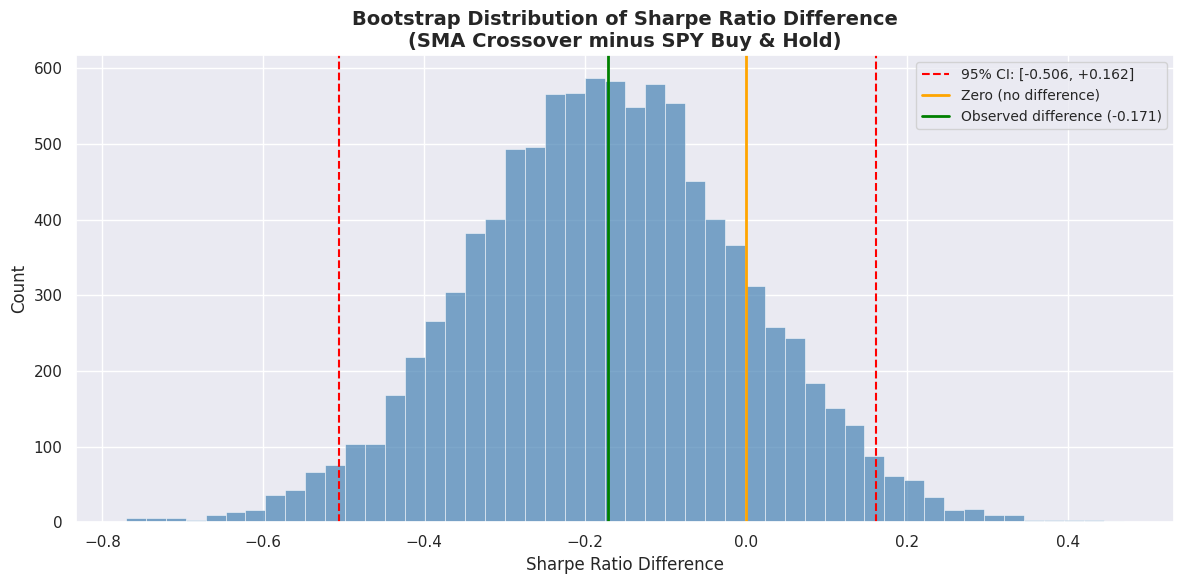

In [11]:
# --- Plot the bootstrap distribution ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(sharpe_diffs, bins=50, color='steelblue', alpha=0.7,
        edgecolor='white', linewidth=0.5)

# Mark the confidence interval
ax.axvline(x=ci_lower, color='red', linewidth=1.5, linestyle='--',
           label=f'95% CI: [{ci_lower:+.3f}, {ci_upper:+.3f}]')
ax.axvline(x=ci_upper, color='red', linewidth=1.5, linestyle='--')

# Mark zero (the null hypothesis: no difference)
ax.axvline(x=0, color='orange', linewidth=2, linestyle='-',
           label='Zero (no difference)')

# Mark the actual observed difference
ax.axvline(x=actual_diff, color='green', linewidth=2, linestyle='-',
           label=f'Observed difference ({actual_diff:+.3f})')

ax.set_title('Bootstrap Distribution of Sharpe Ratio Difference\n'
             '(SMA Crossover minus SPY Buy & Hold)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sharpe Ratio Difference')
ax.set_ylabel('Count')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The bootstrap confirms the paired t-test result, and the chart makes it visually intuitive.

The distribution is centered around -0.171, slightly to the left of zero. This means that in most resampled versions of history, the crossover strategy has a lower Sharpe than SPY. The observed difference of -0.171 (green line) sits right at the center of the distribution, which tells us our specific historical sample is typical, not an outlier.

But zero (the orange line) is well inside the distribution. In a meaningful fraction of bootstrap resamples, the crossover's Sharpe actually exceeded SPY's. The 95% confidence interval runs from -0.506 to +0.162, a wide range that comfortably includes zero. We cannot rule out the possibility that the true Sharpe difference is zero, or even slightly positive in the crossover's favor.

The width of the interval is the most important takeaway. A span of 0.668 Sharpe ratio units means our estimate of the difference is extremely imprecise. We know the crossover probably trails SPY, but we cannot say by how much with any confidence. The interval is wide because daily returns are noisy, and Sharpe ratios compound that noise by dividing one noisy quantity (mean return) by another (standard deviation).

Compare this to the Notebook 6.4 bootstrap on Kalman vs SMA, which had a 95% CI of [-0.152, +0.211]. That interval was narrower because both strategies shared 80% of their portfolio in SPY, so the daily return differences were much smaller and less noisy. The crossover vs SPY comparison has wider differences on cash days (one strategy earning zero while SPY moves), which inflates the noise and widens the interval.

Both tests, the paired t-test and the bootstrap, point to the same conclusion: the crossover's underperformance is not statistically significant at the 5% level. The two methods approach the question differently (the t-test works on daily return differences, the bootstrap works on Sharpe ratio differences) but they agree. When two independent methods agree, you can be more confident in the result.

What does this mean for you when building and testing strategies? Use both tests. If you compare a new strategy against a benchmark and both the paired t-test and the bootstrap say the difference is significant, you have strong evidence. If both say it is not significant, you have uncertainty, and you should not make major decisions based on that comparison alone. If the two methods disagree, dig deeper: look at the sample size, the noise level, and whether the return distribution has unusual properties that might affect one test more than the other.

Most importantly, run these tests before you get attached to a result. It is much easier to accept that a Sharpe difference is not significant before you have spent three months building infrastructure around the "winning" strategy. Test first, build second. Every time.

## Section 5: Practical Guidelines for Strategy Comparison

We have built two statistical tests and seen them in action. This section consolidates what we learned into practical rules you can apply to any strategy comparison. These are not academic guidelines. They are the rules I wish someone had given me before I spent years comparing strategies without testing whether the differences were real.

In [12]:
# --- When to use which test: summary table ---

guidelines = {
    'Question': [
        'Is the mean return difference nonzero?',
        'Is the Sharpe ratio difference nonzero?',
        'Quick screening of many variants',
        'Final evaluation of best candidate',
    ],
    'Use This Test': [
        'Paired t-test',
        'Bootstrap CI on Sharpe difference',
        'Paired t-test (fast, one line with scipy)',
        'Both (they should agree)',
    ],
    'What It Assumes': [
        'Differences roughly normal (OK for daily returns)',
        'Nothing (distribution-free)',
        'Same as paired t-test',
        'N/A',
    ],
    'Watch Out For': [
        'Fat tails can reduce power',
        'Slow with very large samples',
        'Multiple comparisons (apply Bonferroni)',
        'Disagreement means dig deeper',
    ],
}

df_guidelines = pd.DataFrame(guidelines).set_index('Question')
print("When to Use Which Test")
print("=" * 175)
print(df_guidelines.to_string())

When to Use Which Test
                                                                     Use This Test                                    What It Assumes                            Watch Out For
Question                                                                                                                                                                      
Is the mean return difference nonzero?                               Paired t-test  Differences roughly normal (OK for daily returns)               Fat tails can reduce power
Is the Sharpe ratio difference nonzero?          Bootstrap CI on Sharpe difference                        Nothing (distribution-free)             Slow with very large samples
Quick screening of many variants         Paired t-test (fast, one line with scipy)                              Same as paired t-test  Multiple comparisons (apply Bonferroni)
Final evaluation of best candidate                        Both (they should agree)                    

### 5.1 How Much Data Do You Need?

This is the question everyone asks, and the honest answer is: more than you think. The amount of data required to detect a real difference depends on three things: the size of the effect, the noise in the data, and the significance level you demand.

A rough rule of thumb for daily return data: to detect a difference of X in annualized Sharpe ratio at the 5% significance level with 80% power, you need approximately (2.8 / X)^2 years of daily data. Here is what that looks like in practice.

In [14]:
# --- How much data do you need? ---
# Approximate years of daily data required to detect a given Sharpe
# difference at 5% significance with 80% power.
#
# This is a simplified approximation based on the standard error of
# the Sharpe ratio estimator: SE(Sharpe) ≈ 1 / sqrt(n_years).
# To detect a difference of delta_sharpe, you need the difference
# to be about 2.8 standard errors from zero (1.96 for significance
# + 0.84 for 80% power).
#
# Formula: n_years ≈ (2.8 / delta_sharpe)^2

sharpe_diffs_to_detect = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]

print("Approximate Years of Daily Data Needed")
print("to Detect a Sharpe Ratio Difference")
print("(5% significance, 80% power)")
print("=" * 45)
print(f"{'Sharpe Difference':<20} {'Years Needed':>15}")
print("-" * 45)

for delta in sharpe_diffs_to_detect:
    years = (2.8 / delta) ** 2
    print(f"{delta:<20.2f} {years:>15.0f}")

print(f"\n--- For reference ---")
print(f"Kalman vs SMA difference (Ch 6.4):     ~0.03")
print(f"Years needed to detect 0.03:           {(2.8 / 0.03) ** 2:,.0f}")
print(f"Data we actually have:                 ~14 years")

Approximate Years of Daily Data Needed
to Detect a Sharpe Ratio Difference
(5% significance, 80% power)
Sharpe Difference       Years Needed
---------------------------------------------
0.05                            3136
0.10                             784
0.15                             348
0.20                             196
0.30                              87
0.50                              31

--- For reference ---
Kalman vs SMA difference (Ch 6.4):     ~0.03
Years needed to detect 0.03:           8,711
Data we actually have:                 ~14 years


These numbers should be sobering.

To detect a Sharpe difference of 0.10 (the gap between our crossover strategy at 0.715 and SPY at 0.886), you need roughly 784 years of daily data. We have 14. To detect a difference of 0.20, which most practitioners would consider a meaningful improvement, you still need 196 years. Even a large difference of 0.50 requires 31 years.

The Kalman vs SMA comparison from Notebook 6.4 had an observed Sharpe difference of about 0.03. To confirm that difference with statistical confidence, you would need approximately 8,711 years of daily data. This is why the bootstrap confidence interval in Notebook 6.4 was wide enough to include zero: 14 years of data has no chance of resolving a difference that small.

This is not a flaw in the tests. It is a fact about financial data. Daily returns have a signal-to-noise ratio that is extremely low. The effects we care about (small improvements in risk-adjusted performance) are tiny relative to the daily variation in returns. The tests are working correctly. The data simply does not contain enough information to answer the question with confidence.

### 5.2 What to Do When Significance Is Out of Reach

For most practical strategy comparisons, you will not reach statistical significance. This does not mean the comparison is useless. It means you need to change how you use the results.

First, use significance tests as a filter for bad ideas, not a proof of good ones. If a strategy change is significantly worse (like the Fourier filter in Notebook 6.4 at p=0.007), that is strong evidence to reject it. The test earned its keep by preventing a bad decision, even if it cannot confirm the good decisions.

Second, look at the direction and magnitude of the point estimate, not just the p-value. The Kalman filter's Sharpe was 0.03 higher than the SMA, the bootstrap mean was positive, and the structural advantages (causal, adaptive, no boundary effects) are real. None of that constitutes proof, but all of it constitutes reason to keep investigating rather than abandon the idea.

Third, accumulate evidence from multiple independent sources. A strategy that looks better in a backtest, makes economic sense, survives parameter sensitivity analysis, holds up out of sample, and performs well in walk-forward testing has far more evidence behind it than a strategy that merely passed a single p-value threshold. We build those additional tools in Chapters 8 and 9.

Fourth, be honest about what you know and what you do not. In the chapter text, we will revisit the Notebook 6.4 verdict with the full framework from this chapter. The conclusion will be the same: the SMA wins as the baseline because nothing significantly beat it, the Kalman filter is a promising lead worth pursuing with better tools, and the Fourier and wavelet filters are rejected. That is a disciplined, honest conclusion. It is not as satisfying as declaring a winner, but it is correct.

### 5.3 Connection to Notebook 6.4

In Notebook 6.4, we applied both the paired t-test and bootstrap confidence interval to compare six VIX filters against the 90-day SMA baseline. Now you have the full context to understand those results.

The paired t-test showed that two filters were significantly worse than the SMA: Fourier (p=0.007) and wavelet trend (p=0.034). The EMA (p=0.952), Kalman (p=0.441), and wavelet denoise (p=0.245) were not significantly different. After Bonferroni correction for six comparisons (threshold of 0.0083), only Fourier remained significant.

The bootstrap 95% confidence interval on the Kalman vs SMA Sharpe difference was [-0.152, +0.211]. Zero sat comfortably inside the interval. The mean difference was +0.032, positive but small. Given that detecting a Sharpe difference of 0.03 would require roughly 8,700 years of data, this result was inevitable. No statistical test could have confirmed the Kalman filter's advantage with the data we had.

In the chapter text, we will walk through the Notebook 6.4 metrics table and statistical tests one more time, using the vocabulary and framework from this chapter. The conclusion is the same, but your understanding of why we reached it is now much deeper.

This completes Notebook 7.3. You now have the tools to measure strategy performance (Notebook 7.1), automate those measurements with professional libraries (Notebook 7.2), and test whether the differences you observe are real or noise (Notebook 7.3). In Chapter 8, we move from evaluating strategies to backtesting them properly, accounting for the transaction costs, slippage, and rebalancing mechanics that our simplified return calculations have ignored.